# **Segmentation**

Goal:
- Define policy-relevant subpopulations where ATEs may differ

- **NOT** user clustering


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from dotenv import load_dotenv
import pyarrow as pa, pyarrow.parquet as pq, pyarrow.compute as pc

In [2]:
load_dotenv()
PROPENSITY_PATH = os.getenv("PROPENSITY_PATH")
propensity_path = PROPENSITY_PATH

In [3]:
data = duckdb.sql(f"""
    SELECT *
    FROM read_parquet('{propensity_path}')
    LIMIT 10
""").to_df()
data.columns

Index(['uid', 'item_id', 'is_algo', 'day', 'log_u_prior_plays',
       'u_algo_rate_smoothed', 'log_item_prior_plays', 'u_item_seen_before',
       'u_like_rate_smoothed', 'item_like_rate_smoothed',
       'u_dislike_rate_smoothed', 'item_dislike_rate_smoothed', 'y_like_24h',
       'y_dislike_24h', 'propensity'],
      dtype='object')

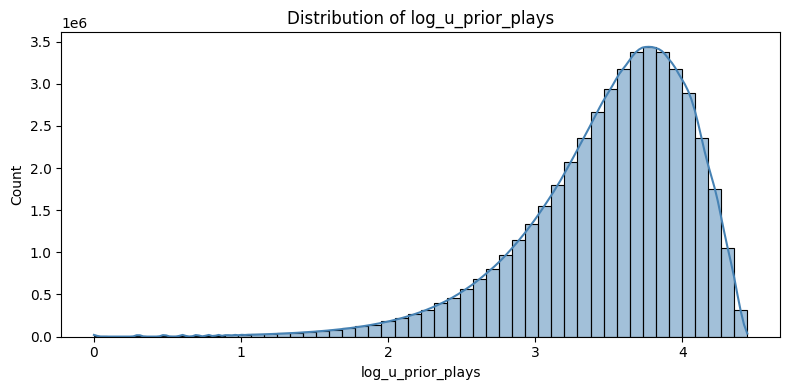

In [ ]:
# log_u_prior_plays
log_u_prior_plays = duckdb.sql(f"""
    SELECT log_u_prior_plays
    FROM read_parquet('{propensity_path}')
""").to_df()

plt.figure(figsize=(8, 4))
sns.histplot(log_u_prior_plays, bins=100, kde=True, color='steelblue')
plt.title('Distribution of log_u_prior_plays')
plt.xlabel('log_u_prior_plays')
plt.ylabel('Count')
plt.tight_layout()


- Strong right-skew around 3.5-4, meaning very few "new users"
- Segmentation:
    - [0, 3] - light listeners
    - [3, 4] - average listeners   
    - [4, 5] - heavy listeners

In [14]:
# log_u_prior_plays segments
log_u_prior_plays_segment_summary = duckdb.sql(f"""
    SELECT
        CASE
            WHEN log_u_prior_plays >= 0 AND log_u_prior_plays <= 3 THEN 'light_segment'
            WHEN log_u_prior_plays > 3 AND log_u_prior_plays <= 4 THEN 'average_segment'
            WHEN log_u_prior_plays > 4 THEN 'heavy_segment'
            ELSE NULL
        END AS u_prior_plays_segment,
        COUNT(*) AS total_count,
        100 * AVG(CASE WHEN is_algo = 1 THEN 1 ELSE 0 END) AS pct_treatment,
        100 - 100 * AVG(CASE WHEN is_algo = 1 THEN 1 ELSE 0 END) AS pct_control
    FROM read_parquet('{propensity_path}')
    WHERE log_u_prior_plays IS NOT NULL
    GROUP BY 1
    HAVING u_prior_plays_segment IS NOT NULL
    ORDER BY 1
""").to_df()

log_u_prior_plays_segment_summary


,u_prior_plays_segment,total_count,pct_treatment,pct_control
0,average_segment,30365632,47.988700,52.011300
1,heavy_segment,8266754,49.621605,50.378395
2,light_segment,7834826,48.365937,51.634063


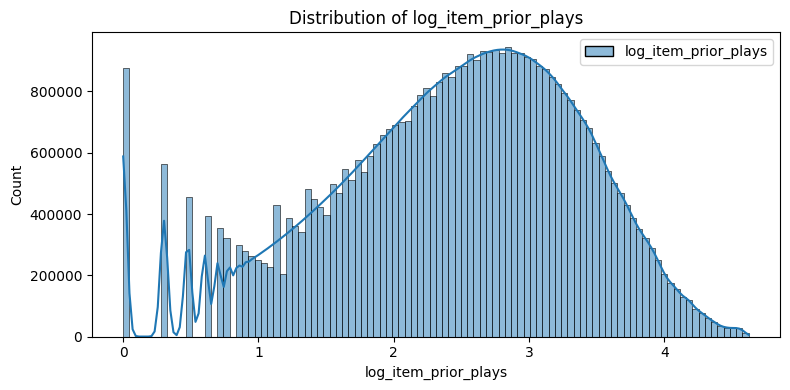

In [6]:
# log_item_prior_plays
log_item_prior_plays = duckdb.sql(f"""
    SELECT log_item_prior_plays
    FROM read_parquet('{propensity_path}')
""").to_df()

plt.figure(figsize=(8, 4))
sns.histplot(log_item_prior_plays, bins=100, kde=True, color='steelblue')
plt.title('Distribution of log_item_prior_plays')
plt.xlabel('log_item_prior_plays')
plt.ylabel('Count')
plt.tight_layout()

- Spikes at low popularity (discrete)
- Segmentation:
    - [0, 0.2] - brand new
    - [0.2, 1] - niche
    - [1, 3] - popular 
    - [3, 5] - very popular

In [15]:
# log_item_prior_plays segments
log_item_prior_plays_segment_summary = duckdb.sql(f"""
    SELECT
        CASE
            WHEN log_item_prior_plays >= 0 AND log_item_prior_plays <= 0.2 THEN 'new_segment'
            WHEN log_item_prior_plays > 0.2 AND log_item_prior_plays <= 1 THEN 'niche_segment'
            WHEN log_item_prior_plays > 1 AND log_item_prior_plays <= 3 THEN 'popular_segment'
            WHEN log_item_prior_plays > 3 THEN 'very_popular_segment'
            ELSE NULL
        END AS item_prior_plays_segment,
        COUNT(*) AS total_count,
        100 * AVG(CASE WHEN is_algo = 1 THEN 1 ELSE 0 END) AS pct_treatment,
        100 - 100 * AVG(CASE WHEN is_algo = 1 THEN 1 ELSE 0 END) AS pct_control
    FROM read_parquet('{propensity_path}')
    WHERE log_item_prior_plays IS NOT NULL
    GROUP BY 1
    HAVING item_prior_plays_segment IS NOT NULL
    ORDER BY 1
""").to_df()

log_item_prior_plays_segment_summary

,item_prior_plays_segment,total_count,pct_treatment,pct_control
0,new_segment,877168,37.313491,62.686509
1,niche_segment,3184875,45.863464,54.136536
2,popular_segment,28332239,49.763098,50.236902
3,very_popular_segment,14072930,46.731981,53.268019


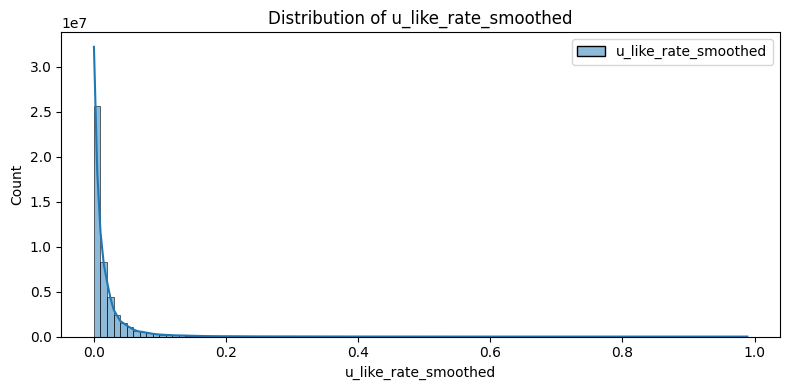

In [ ]:
# u_like_rate_smoothed
u_like_rate_smoothed = duckdb.sql(f"""
    SELECT u_like_rate_smoothed
    FROM read_parquet('{propensity_path}')
""").to_df()

plt.figure(figsize=(8, 4))
sns.histplot(u_like_rate_smoothed, bins=100, kde=True, color='steelblue')
plt.title('Distribution of u_like_rate_smoothed')
plt.xlabel('u_like_rate_smoothed')
plt.ylabel('Count')
plt.tight_layout()

- Expected heavy left skew 
- Segmentation:
    - [0, 0.1] - rare likers
    - [0.1, 1] - engaged likers

In [5]:
u_like_rate_smoothed_segment_summary = duckdb.sql(f"""
    SELECT
        CASE
            WHEN u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1 THEN 'rare_likers_segment'
            WHEN u_like_rate_smoothed > 0.1 AND u_like_rate_smoothed <= 1 THEN 'engaged_likers_segment'
            ELSE NULL
        END AS u_like_rate_smoothed_segment,
        COUNT(*) AS total_count,
        100 * AVG(CASE WHEN is_algo = 1 THEN 1 ELSE 0 END) AS pct_treatment,
        100 - 100 * AVG(CASE WHEN is_algo = 1 THEN 1 ELSE 0 END) AS pct_control
    FROM read_parquet('{propensity_path}')
    WHERE u_like_rate_smoothed IS NOT NULL
    GROUP BY 1
    HAVING u_like_rate_smoothed_segment IS NOT NULL
    ORDER BY 1
""").to_df()

u_like_rate_smoothed_segment_summary

,u_like_rate_smoothed_segment,total_count,pct_treatment,pct_control
0,engaged_likers_segment,1401861,46.466376,53.533624
1,rare_likers_segment,45065351,48.401179,51.598821
